# Employee Attrition Prediction

## Notebook 4A: Imbalanced Learning Experiments

### Objective

The objective of this notebook is to investigate whether handling class imbalance improves the predictive performance of the employee attrition models.

Unlike Notebook 4, which focused on optimizing model hyperparameters, this notebook focuses on improving the quality of the training data by applying resampling techniques.

The performance of the models trained on balanced data will be compared against the tuned models trained on the original dataset.

In [5]:
# =============================================================================
# Import Required Libraries
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [6]:
# =============================================================================
# Load Dataset
# =============================================================================

DATA_PATH = Path("../dataset/employee_attrition.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
# =============================================================================
# Remove Constant and Identifier Columns
# =============================================================================

columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

print(df.shape)

(1470, 31)


In [8]:
# =============================================================================
# Separate Features and Target
# =============================================================================

X = df.drop(columns="Attrition")

y = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

print(X.shape)
print(y.shape)

(1470, 30)
(1470,)


In [9]:
# =============================================================================
# Train-Test Split
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1176, 30)
Testing Shape: (294, 30)


In [11]:
# =============================================================================
# Class Distribution
# =============================================================================

distribution = y_train.value_counts()

percentage = round(

    y_train.value_counts(normalize=True)*100,

    2

)

class_df = pd.DataFrame({

    "Count":distribution,

    "Percentage":percentage

})

class_df.index = [

    "No Attrition",

    "Attrition"

]

class_df

,Count,Percentage
No Attrition,986,83.84
Attrition,190,16.16


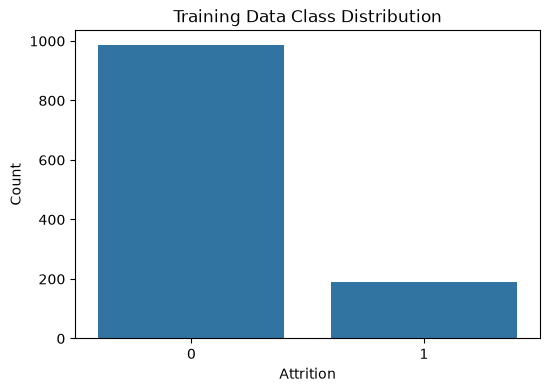

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Training Data Class Distribution")

plt.xlabel("Attrition")

plt.ylabel("Count")

plt.show()

In [13]:
# =============================================================================
# Numerical and Categorical Features
# =============================================================================

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print(f"Numerical Features: {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Numerical Features: 23
Categorical Features: 7


In [14]:
# =============================================================================
# Numerical Pipeline
# =============================================================================

numerical_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# =============================================================================
# Categorical Pipeline
# =============================================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# =============================================================================
# Column Transformer
# =============================================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [15]:
# =============================================================================
# Transform Dataset
# =============================================================================

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(1176, 51)
(294, 51)


In [16]:
# =============================================================================
# Evaluation Function
# =============================================================================

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    results = {

        "Accuracy":accuracy_score(y_test,y_pred),

        "Precision":precision_score(y_test,y_pred),

        "Recall":recall_score(y_test,y_pred),

        "F1 Score":f1_score(y_test,y_pred),

        "ROC AUC":roc_auc_score(y_test,y_prob)

    }

    return results

In [31]:
# =============================================================================
# Logistic Regression
# =============================================================================

lr_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

            LogisticRegression(
    C=1,
    penalty="l1",
    solver="liblinear",
    class_weight=None,
    random_state=42,
    max_iter=1000
)

        )

    ]

)

lr_pipeline.fit(

    X_train,

    y_train

)

lr_results = evaluate_model(

    lr_pipeline,

    X_test,

    y_test

)

In [32]:
# =============================================================================
# Support Vector Machine
# =============================================================================

svm_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

            SVC(
    C=10,
    kernel="linear",
    gamma="scale",
    class_weight=None,
    probability=True,
    random_state=42
)
        )

    ]

)

svm_pipeline.fit(

    X_train,

    y_train

)

svm_results = evaluate_model(

    svm_pipeline,

    X_test,

    y_test

)

In [33]:
# =============================================================================
# XGBoost
# =============================================================================

xgb_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

            XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_estimators=200,

    max_depth=5,

    learning_rate=0.2,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_weight=3,

    scale_pos_weight=scale_pos_weight
)

        )

    ]

)

xgb_pipeline.fit(

    X_train,

    y_train

)

xgb_results = evaluate_model(

    xgb_pipeline,

    X_test,

    y_test

)

In [34]:
# =============================================================================
# Original Model Results
# =============================================================================

original_results = pd.DataFrame({

    "Logistic Regression":lr_results,

    "Support Vector Machine":svm_results,

    "XGBoost":xgb_results

}).T

original_results

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.863946,0.629630,0.361702,0.459459,0.809114
Support Vector Machine,0.867347,0.666667,0.340426,0.450704,0.813378
XGBoost,0.853741,0.590909,0.276596,0.376812,0.762856


## Experiment 1 Summary

The three shortlisted machine learning models were trained using the original imbalanced training dataset without applying any imbalance handling technique.

These results serve as the baseline for Notebook 4A. In the following experiments, class weighting and SMOTE will be applied to determine whether handling class imbalance improves predictive performance.

In [35]:
# =============================================================================
# Logistic Regression (Tuned + Class Weight)
# =============================================================================

lr_balanced = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

            LogisticRegression(
    C=1,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

        )

    ]

)

lr_balanced.fit(X_train, y_train)

lr_balanced_results = evaluate_model(

    lr_balanced,

    X_test,

    y_test

)

In [36]:
# =============================================================================
# Support Vector Machine (Tuned + Class Weight)
# =============================================================================

svm_balanced = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

            SVC(
    C=10,
    kernel="linear",
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

        )

    ]

)

svm_balanced.fit(X_train, y_train)

svm_balanced_results = evaluate_model(

    svm_balanced,

    X_test,

    y_test

)

In [23]:
negative = y_train.value_counts()[0]

positive = y_train.value_counts()[1]

scale_pos_weight = negative / positive

print(scale_pos_weight)

5.189473684210526


In [37]:
# =============================================================================
# XGBoost (scale_pos_weight)
# =============================================================================

xgb_balanced = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

            XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_estimators=200,

    max_depth=5,

    learning_rate=0.2,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_weight=3,

    scale_pos_weight=scale_pos_weight
)
        )

    ]

)

xgb_balanced.fit(

    X_train,

    y_train

)

xgb_balanced_results = evaluate_model(

    xgb_balanced,

    X_test,

    y_test

)

In [38]:
balanced_results = pd.DataFrame({

    "Logistic Regression": lr_balanced_results,

    "Support Vector Machine": svm_balanced_results,

    "XGBoost": xgb_balanced_results

}).T

balanced_results

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.755102,0.352941,0.638298,0.454545,0.800672
Support Vector Machine,0.768707,0.373494,0.659574,0.476923,0.796020
XGBoost,0.853741,0.590909,0.276596,0.376812,0.762856


## Experiment 2 Summary

This experiment investigated whether assigning greater importance to the minority class improves model performance.

For Logistic Regression and Support Vector Machine, the `class_weight="balanced"` parameter was used.

For XGBoost, the `scale_pos_weight` parameter was calculated from the class distribution and used to increase the contribution of the minority class during training.

The resulting performance will be compared with the original tuned models and the SMOTE-based models in the next experiment.

In [39]:
# =============================================================================
# Logistic Regression + SMOTE
# =============================================================================

lr_smote = ImbPipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("smote", SMOTE(random_state=42)),

        ("classifier",

            LogisticRegression(

    C=1,

    penalty="l1",

    solver="liblinear",

    random_state=42,

    max_iter=1000
)

        )

    ]

)

lr_smote.fit(X_train, y_train)

lr_smote_results = evaluate_model(

    lr_smote,

    X_test,

    y_test

)

In [40]:
# =============================================================================
# Support Vector Machine + SMOTE
# =============================================================================

svm_smote = ImbPipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("smote", SMOTE(random_state=42)),

        ("classifier",

            SVC(

    C=10,

    kernel="linear",

    gamma="scale",

    probability=True,

    random_state=42
)
        )

    ]

)

svm_smote.fit(X_train, y_train)

svm_smote_results = evaluate_model(

    svm_smote,

    X_test,

    y_test

)

In [41]:
# =============================================================================
# XGBoost + SMOTE
# =============================================================================

xgb_smote = ImbPipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("smote", SMOTE(random_state=42)),

        ("classifier",

            XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_estimators=200,

    max_depth=5,

    learning_rate=0.2,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_weight=3
)
        )

    ]

)

xgb_smote.fit(

    X_train,

    y_train

)

xgb_smote_results = evaluate_model(

    xgb_smote,

    X_test,

    y_test

)

In [42]:
# =============================================================================
# SMOTE Results
# =============================================================================

smote_results = pd.DataFrame({

    "Logistic Regression": lr_smote_results,

    "Support Vector Machine": svm_smote_results,

    "XGBoost": xgb_smote_results

}).T

smote_results

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.768707,0.363636,0.595745,0.451613,0.792402
Support Vector Machine,0.775510,0.376623,0.617021,0.467742,0.793824
XGBoost,0.857143,0.608696,0.297872,0.400000,0.789129


## Experiment 3 Summary

SMOTE (Synthetic Minority Oversampling Technique) was applied only to the training data using an `imblearn.pipeline.Pipeline`.

The preprocessing, oversampling, and model training steps were combined into a single pipeline to prevent data leakage.

The performance of the SMOTE-based models will now be compared with the original tuned models and the class-weighted models.

In [43]:
all_results = pd.concat(
    [
        original_results.assign(Strategy="Original"),
        balanced_results.assign(Strategy="Class Weight"),
        smote_results.assign(Strategy="SMOTE")
    ]
)

all_results = all_results.reset_index().rename(columns={"index": "Model"})

all_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Strategy
0,Logistic Regression,0.863946,0.629630,0.361702,0.459459,0.809114,Original
1,Support Vector Machine,0.867347,0.666667,0.340426,0.450704,0.813378,Original
2,XGBoost,0.853741,0.590909,0.276596,0.376812,0.762856,Original
3,Logistic Regression,0.755102,0.352941,0.638298,0.454545,0.800672,Class Weight
4,Support Vector Machine,0.768707,0.373494,0.659574,0.476923,0.796020,Class Weight
5,XGBoost,0.853741,0.590909,0.276596,0.376812,0.762856,Class Weight
6,Logistic Regression,0.768707,0.363636,0.595745,0.451613,0.792402,SMOTE
7,Support Vector Machine,0.775510,0.376623,0.617021,0.467742,0.793824,SMOTE
8,XGBoost,0.857143,0.608696,0.297872,0.400000,0.789129,SMOTE


In [44]:
all_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Strategy
4,Support Vector Machine,0.768707,0.373494,0.659574,0.476923,0.796020,Class Weight
7,Support Vector Machine,0.775510,0.376623,0.617021,0.467742,0.793824,SMOTE
0,Logistic Regression,0.863946,0.629630,0.361702,0.459459,0.809114,Original
3,Logistic Regression,0.755102,0.352941,0.638298,0.454545,0.800672,Class Weight
6,Logistic Regression,0.768707,0.363636,0.595745,0.451613,0.792402,SMOTE
1,Support Vector Machine,0.867347,0.666667,0.340426,0.450704,0.813378,Original
8,XGBoost,0.857143,0.608696,0.297872,0.400000,0.789129,SMOTE
2,XGBoost,0.853741,0.590909,0.276596,0.376812,0.762856,Original
5,XGBoost,0.853741,0.590909,0.276596,0.376812,0.762856,Class Weight


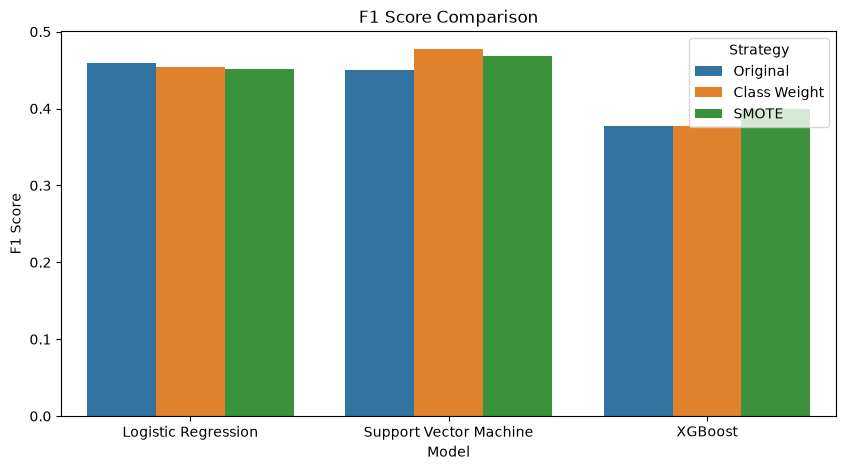

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    data=all_results,
    x="Model",
    y="F1 Score",
    hue="Strategy"
)

plt.title("F1 Score Comparison")

plt.show()

# Conclusion

This notebook investigated the impact of different class imbalance handling strategies on the performance of three shortlisted machine learning models: Logistic Regression, Support Vector Machine (SVM), and XGBoost.

Three approaches were evaluated:

- Original tuned models (no imbalance handling)
- Tuned models with class weighting (`class_weight` or `scale_pos_weight`)
- Tuned models trained using SMOTE

The experimental results showed that the effect of imbalance handling varied across the models.

For Logistic Regression, both class weighting and SMOTE substantially increased Recall (from 36.17% to over 59%), enabling the model to identify more employees at risk of attrition. However, this improvement came with a reduction in Precision and Accuracy, resulting in only a marginal change in the F1-score.

Support Vector Machine demonstrated the greatest benefit from imbalance handling. Using `class_weight="balanced"` improved Recall from 34.04% to 65.96% while also achieving the highest F1-score (0.4769) among all experiments. This indicates that class weighting significantly enhanced the model's ability to detect employees likely to leave while maintaining the best overall balance between Precision and Recall.

For XGBoost, neither class weighting (`scale_pos_weight`) nor SMOTE produced meaningful improvements. The model's performance remained similar to the original tuned version, suggesting that these imbalance handling strategies offered limited benefit for this dataset.

Overall, the experiments demonstrate that imbalance handling should not be applied by default. Its effectiveness depends on both the dataset and the learning algorithm. Comparing multiple strategies through controlled experiments provided evidence for selecting the most appropriate approach rather than relying on assumptions.

Considering the business objective of identifying employees at risk of attrition, the Support Vector Machine with `class_weight="balanced"` achieved the strongest overall performance and was selected as the final model for the next phase of the project.

## Key Takeaways

- Hyperparameter tuning alone did not fully address the effects of class imbalance.
- Class weighting was more effective than SMOTE for Support Vector Machine on this dataset.
- SMOTE improved Recall for Logistic Regression but did not improve the overall F1-score.
- XGBoost showed limited sensitivity to the imbalance handling techniques evaluated.
- Model selection should be based on experimental evidence and business objectives rather than assuming that a particular imbalance handling technique will always improve performance.